In [ ]:
- name: Upgrade system safely
  ansible.builtin.dnf:
    name: "*"
    state: latest
    update_only: yes

- name: Disable swap immediately
  ansible.builtin.command: swapoff -a
  changed_when: false

- name: Disable swap permanently in /etc/fstab
  ansible.builtin.replace:
    path: /etc/fstab
    regexp: '^([^#].*\s+swap\s+.*)$'
    replace: '# \1'


- name: Ensure required kernel modules config file
  copy:
    dest: /etc/modules-load.d/k8s.conf
    content: |
      overlay
      br_netfilter
    owner: root
    group: root
    mode: '0644'

- name: Load overlay module
  community.general.modprobe:
    name: overlay
    state: present

- name: Load br_netfilter module
  community.general.modprobe:
    name: br_netfilter
    state: present

- name: Add Docker CE repository
  ansible.builtin.get_url:
    url: https://download.docker.com/linux/centos/docker-ce.repo
    dest: /etc/yum.repos.d/docker-ce.repo
    mode: '0644'

- name: Set SELinux to permissive
  ansible.posix.selinux:
    policy: targeted
    state: permissive

- name: Disable firewalld
  ansible.builtin.systemd:
    name: firewalld
    enabled: false
    state: stopped

- name: Install Packages
  ansible.builtin.dnf:
    name: 
      - containerd.io
      - containernetworking-plugins
      - tcptraceroute 
      - nc
      - tcpdump
      - vim-enhanced
      - wget
      - unzip
      - git 
      - bind-utils 
      - mtr 
      - tcpdump 
      - nmap-ncat 
      - htop 
      - sysstat 
      - iotop 
      - open-vm-tools 
      - smartmontools 
      - pciutils 
      - usbutils
      - net-tools
      - ipvsadm
      - helm
    state: present


# - name: Ensure firewalld is installed
#   ansible.builtin.dnf:
#     name: firewalld
#     state: present

# - name: Enable and start firewalld
#   ansible.builtin.systemd:
#     name: firewalld
#     enabled: true
#     state: started
  

# - name: Open Kubernetes control-plane ports
#   ansible.posix.firewalld:
#     port: "{{ item }}"
#     permanent: true
#     state: enabled
#     immediate: true
#   loop:
#     - 6443/tcp
#     - 2379-2380/tcp
#     - 10250/tcp
#     - 10257/tcp
#     - 10259/tcp
#     - 4789/udp
#     - 10250/tcp
#     - 30000-32767/tcp
#     - 4789/udp
#     - 179/tcp
#     - 8472/udp
#     - 80/tcp
#     - 443/tcp
#     - 8081/tcp

# - name: Reload firewalld
#   ansible.builtin.service:
#     name: firewalld
#     state: reloaded


- name: Add the Kubernetes yum repository.
  ansible.builtin.yum_repository:
    name: Kubernetes
    description: Kubernetes
    file: /etc/yum.repos.d/kubernetes.repo
    baseurl: https://pkgs.k8s.io/core:/stable:/v1.35/rpm/
    gpgcheck: true
    gpgkey: https://pkgs.k8s.io/core:/stable:/v1.35/rpm/repodata/repomd.xml.key
    enabled: true
    exclude: kubelet kubeadm kubectl cri-tools kubernetes-cni


- name: Install kubelet, kubeadm , kubectl and containerd
  ansible.builtin.dnf:
    name: 
      - kubelet 
      - kubeadm 
      - kubectl 
    state: present
    disable_excludes: Kubernetes



- name: Copy all CNI binaries to /opt/cni/bin
  shell: cp /usr/libexec/cni/* /opt/cni/bin/
  become: true

- name: Enable the kubelet service before running kubeadm
  ansible.builtin.systemd_service:
    state: started
    name: kubelet
    enabled: true


- name: Enable the containerd service before running kubeadm
  ansible.builtin.systemd_service:
    name: containerd
    enabled: true
    state: started


- name: Create containerd config directory
  ansible.builtin.file:
    path: /etc/containerd
    state: directory
    mode: '0755'


# ------- Kube Network Settings -------

- name: Configure kernel sysctl parameters for Kubernetes
  ansible.posix.sysctl:
    name: "{{ item.key }}"
    value: "{{ item.value }}"
    sysctl_file: /etc/sysctl.d/k8s.conf
    state: present
    reload: true
  loop:
    - { key: 'net.ipv4.ip_forward', value: '1' }
    - { key: 'net.bridge.bridge-nf-call-iptables', value: '1' }
    - { key: 'net.bridge.bridge-nf-call-ip6tables', value: '1' }
    - { key: 'net.ipv4.conf.all.rp_filter', value: '2' }
    - { key: 'net.ipv4.conf.default.rp_filter', value: '2' }

- name: Disable IPv6
  ansible.posix.sysctl:
    name: "{{ item }}"
    value: '1'
    state: present
    reload: true
  loop:
    - net.ipv6.conf.all.disable_ipv6
    - net.ipv6.conf.default.disable_ipv6
  

- name: Generate default containerd config
  ansible.builtin.command:  containerd config default
  register: containerd_config
  changed_when: false

- name: Write containerd config to /etc/containerd/config.toml
  ansible.builtin.copy:
    content: "{{ containerd_config.stdout }}"
    dest: /etc/containerd/config.toml
    owner: root
    group: root
    mode: '0644'

- name: Update SystemdCgroup to true in containerd config
  ansible.builtin.replace:
    path: /etc/containerd/config.toml
    regexp: 'SystemdCgroup = false'
    replace: 'SystemdCgroup = true'
  
- name: Restart containerd
  ansible.builtin.systemd_service:
    name: containerd
    state: restarted

# ----------------------- Auto-Complete

- name: Auto Complete kube
  ansible.builtin.dnf:
    name: bash-completion
    state: present

- name: Add kubectl completion script to .bashrc
  ansible.builtin.lineinfile:
    path: /root/.bashrc
    line: 'source <(kubectl completion bash)'

- name: Apply changes to .bashrc
  ansible.builtin.shell: 'source /root/.bashrc'
  args:
    executable: /bin/bash
  changed_when: false

# ----------------------- reload Daemon
- name: Reload Daemon
  ansible.builtin.systemd_service:
    daemon_reload: true

- name: Ensure python3-pip is installed
  ansible.builtin.package:
    name: python3-pip
    state: present

- name: Install kubernetes python library
  ansible.builtin.pip:
    name: kubernetes
    state: present

cat > kube-vip.sh << 'OF'
#!/bin/bash
# =============================================================================
# Kube-VIP Static Pod Setup Script
# Purpose: Deploy Kube-VIP as a static pod for HA Kubernetes control plane
# Author: Generated for Khaled
# =============================================================================

set -euo pipefail  # Best practice: exit on error, undefined vars, pipe failures

# ========================= CONFIGURATION =========================
VIP="172.16.6.85"
INTERFACE="ens192"
POD_NETWORK_CIDR="10.244.0.0/16"

# Colors for better output
RED='\033[0;31m'
GREEN='\033[0;32m'
YELLOW='\033[1;33m'
BLUE='\033[0;34m'
NC='\033[0m' # No Color

log() { echo -e "${BLUE}[INFO]${NC} $1" }

success() { echo -e "${GREEN}[SUCCESS]${NC} $1" }

warn() { echo -e "${YELLOW}[WARN]${NC} $1" }

error() {
    echo -e "${RED}[ERROR]${NC} $1" >&2
    exit 1
}

# Check if running as root
if [[ $EUID -ne 0 ]]; then
    error "This script must be run as root"
fi

log "Starting Kube-VIP + kubeadm initialization setup..."

# =========================1. GET LATEST KUBE-VIP VERSION =========================
log "1. Fetching latest kube-vip version..."
KVVERSION=$(curl -sL https://api.github.com/repos/kube-vip/kube-vip/releases/latest | \
            jq -r '.tag_name' || echo "v0.8.0")

if [[ -z "$KVVERSION" || "$KVVERSION" == "null" ]]; then
    warn "Failed to fetch latest version, using fallback v0.8.0"
    KVVERSION="v0.8.0"
fi

success "✅ Using kube-vip version: $KVVERSION"

# =========================2. SETUP KUBE-VIP ALIAS =========================
log "2. Setting up kube-vip command..."

# Create a proper wrapper script with version embedded
cat > /usr/local/bin/kube-vip << EOF
#!/bin/bash
# Kube-VIP wrapper - Version: ${KVVERSION}

KVVERSION="${KVVERSION}"
IMAGE="ghcr.io/kube-vip/kube-vip:\${KVVERSION}"

# Pull image if not present
if ! ctr images ls | grep -q "kube-vip:\${KVVERSION}"; then
    echo "Pulling kube-vip image: \${IMAGE}" >&2
    ctr image pull "\${IMAGE}" >/dev/null 2>&1 || {
        echo "Failed to pull kube-vip image" >&2
        exit 1
    }
fi

ctr run --rm --net-host "\${IMAGE}" vip /kube-vip "\$@"
EOF

chmod +x /usr/local/bin/kube-vip

success "✅ kube-vip command installed (version ${KVVERSION})"


# =========================3. CREATE KUBE-VIP MANIFEST =========================
log "3. Generating Kube-VIP static pod manifest..."

mkdir -p /etc/kubernetes/manifests/

kube-vip manifest pod \
    --interface "$INTERFACE" \
    --address "$VIP" \
    --controlplane \
    --services \
    --arp \
    --leaderElection | tee /etc/kubernetes/manifests/kube-vip.yaml

if [[ ! -f /etc/kubernetes/manifests/kube-vip.yaml ]]; then
    error "Failed to create kube-vip manifest"
fi

success "✅ Kube-VIP manifest created at /etc/kubernetes/manifests/kube-vip.yaml"

# ========================= 4 VERIFY IMAGE =========================
log "4. Verifying kube-vip image..."
ctr images ls | grep -i kube-vip || warn "kube-vip image not found in containerd"

log "✅ Starting Kubernetes cluster initialization..."

echo ""
echo "═══════════════════════════════════════════════════════════════"
echo "                  🚀 RUNNING KUBEADM INIT"
echo "═══════════════════════════════════════════════════════════════"
echo ""

kubeadm init \
    --control-plane-endpoint "${VIP}:6443" \
    --upload-certs \
    --pod-network-cidr "$POD_NETWORK_CIDR" \
    --apiserver-cert-extra-sans "$VIP" 2>&1 | tee /var/log/kubeadm-init-$(date +%Y%m%d-%H%M).log

INIT_EXIT_CODE=${PIPESTATUS[0]}

if [[ $INIT_EXIT_CODE -eq 0 ]]; then
    success "✅ Kubernetes control plane initialized successfully!"
    
    # Extract and show join commands clearly
    echo ""
    echo "📋 IMPORTANT JOIN COMMANDS:"
    echo "───────────────────────────────────────────────────────────────"
    grep -A 5 -E "(kubeadm join|certificate-key)" /var/log/kubeadm-init-*.log | tail -n 20
    echo "───────────────────────────────────────────────────────────────"
else
    error "❌ kubeadm init failed with exit code $INIT_EXIT_CODE"
fi

# ========================= SETUP KUBECONFIG =========================
log "Setting up kubectl configuration for current user..."

mkdir -p $HOME/.kube
cp -i /etc/kubernetes/admin.conf $HOME/.kube/config
chown $(id -u):$(id -g) $HOME/.kube/config

success "✅ Kubeconfig configured successfully!"
echo "You can now run: kubectl get nodes"

# ========================= FINAL SUMMARY =========================
echo ""
echo "═══════════════════════════════════════════════════════════════"
echo "🎉 Setup Completed Successfully!"
echo "═══════════════════════════════════════════════════════════════"
echo "VIP Address      : $VIP"
echo "Interface        : $INTERFACE"
echo "Kube-VIP Version : $KVVERSION"
echo "Pod CIDR         : $POD_NETWORK_CIDR"
echo ""
echo "Next steps:"
echo "   1. Install your CNI (Flannel, Calico, Cilium, etc.)"
echo "   2. Join other control plane nodes using the join command above"
echo "   3. kubectl get pods -n kube-system -w"
echo "═══════════════════════════════════════════════════════════════"
OF

kubectl apply -f https://github.com/flannel-io/flannel/releases/latest/download/kube-flannel.yml


for other masters

    kubeadm join 172.16.6.85:6443 --token oms1cx.8y4dzukqz10pcv7g --discovery-token-ca-cert-hash sha256:c4793edbd5ef052ad828083d17f688137374077cc120a39aa1905749916f9ee1 --control-plane --certificate-key 5423b9b7ead54949fab025228d021c33ac9bcc2c95fcb7911c96c0d6d45025cf

- name: Make dir for kubeadm config
  ansible.builtin.file:
    state: directory
    path: "/root/.kube"
    mode: "0755"


- name: Copy config from etc to user dir
  ansible.builtin.copy:
    src: /etc/kubernetes/admin.conf
    dest: "/root/.kube/config"
    mode: '0644'
    remote_src: true
    owner: "root"
    group: "root"

for workers
    kubeadm join 172.16.6.85:6443 --token oms1cx.8y4dzukqz10pcv7g --discovery-token-ca-cert-hash sha256:c4793edbd5ef052ad828083d17f688137374077cc120a39aa1905749916f9ee1 

kubectl apply -f https://raw.githubusercontent.com/metallb/metallb/v0.15.3/config/manifests/metallb-native.yaml

cat > metallb-pool.yaml << 'OF'
apiVersion: metallb.io/v1beta1
kind: IPAddressPool
metadata:
  name: default-pool
  namespace: metallb-system
spec:
  addresses:
  - 172.16.6.90-172.16.6.95
---
apiVersion: metallb.io/v1beta1
kind: L2Advertisement
metadata:
  name: l2adv
  namespace: metallb-system
OF

kubectl apply -f metallb-pool.yaml

kubectl edit configmap kube-proxy -n kube-system

strictARP: true

kubectl rollout restart ds kube-proxy -n kube-system

helm repo add ingress-nginx https://kubernetes.github.io/ingress-nginx
helm repo update

cat > nginx-ingress-values.yaml <<EOF
controller:
  kind: DaemonSet          # ← change from Deployment to DaemonSet
  hostNetwork: true
  dnsPolicy: ClusterFirstWithHostNet
  hostPort:
    enabled: true
    ports:
      http: 80
      https: 443
  service:
    type: LoadBalancer
    loadBalancerIP: 172.16.6.90
  admissionWebhooks:
    enabled: false
  metrics:
    enabled: true
  podDisruptionBudget:
    enabled: true
  tolerations:             # ← add this to run on master nodes
  - key: "node-role.kubernetes.io/control-plane"
    operator: "Exists"
    effect: "NoSchedule"
EOF

helm upgrade --install ingress-nginx ingress-nginx/ingress-nginx \
  --namespace ingress-nginx \
  --create-namespace \
  -f nginx-ingress-values.yaml


In [ ]:
you have the fully steps i need to isntall kubeadm 
i use diferent tools to the install make it like guide using commandl line only 
if there is any deprecated or old version update to suitanble version 
Mention which and groups which command does in any nodes

Create a production-grade clear , simple and oraginize Kubernetes kubeadm deployment guide for a Linux administrator for my team.
(any one can read this will understant )

1. Introduction 
2. Architecture
3. Prerequisites
4. Kubernetes Installation
5. Troubleshooting
6. Backup & Recovery


Requirements:

Kubernetes version X.Y
OS: redhat 9
3 control planes + 3 workers
control-plane-endpoiny using kube-vip
Container runtime: containerd
CNI: Flannel
Ingress: NGINX
Include architecture diagrams
Include networking requirements
Include firewall ports
Explain every command and why it is used
Include troubleshooting section
Include backup and recovery
Output in professional documentation format

as peer the converstion in this project add notes or comments if you need 



I try to install Kubernetes with kubeadm, using Red Hat 
I have
- 3 masters
- 3 workers
- Windows server for my DNS record
I have only on these machines 
So I use
- kube-vip as a static pod for as endpoint 
- metalLB as a load balancer
- nginx as ingress 

Every VM has it's own storage
I have external storage (DELL EMC S42)
The worker only can see this storage 

I have will install clickhouse in my cluster and it will write the data on the storage 
the problem is only one vm can write on the storage 
the traditional (the docs i have from the team ) way is make one vm is active mount the storage and the other two worker backup/standby
if the active is down i will make mount muanal on the storage 
but this way have many Risks i want to make it auto 
there are more than one application write on the storage 
consider only kubernets application will write on the storage 

what is the Solutions i have 
what is the prof way to deal with this case 

it is prodution env

In [ ]:
notes 
I will see the storage as block not filesystem is that correct?
i want only one vm write to fear away iterupted the data


For
Option A — Pacemaker + NFS-Ganesha (recommended for you)

NFS is slow?
the data will be huge 


# StorageClass pointing to the Pacemaker VIP
apiVersion: storage.k8s.io/v1
kind: StorageClass
metadata:
  name: shared-nfs
provisioner: nfs.csi.k8s.io
parameters:
  server: <storage-vip>
  share: /srv/xdr/pv-root
  subDir: ${pvc.metadata.name}
reclaimPolicy: Retain
volumeBindingMode: Immediate

this /srv/xdr/pv-root is should found in all worker ?
a floating VIP 
the ip here will using by kubernetes or the os ?
it will be hideck on the internal network for cluster?
i use kube-vip and metalLB

You have iDRAC on every node — use the fence_ipmilan STONITH agent
should i change any configure on the iDRAC?
what if dont any thing on it ?

Option B — GFS2 (no failover needed)
i will make mount the disk on all heavy ?
here the three nodes will write on the same time ?



Option C — Rook/Ceph (future-proof but complex)
in this way i can only work with disk a cross kubernetes?
is it way is fast?


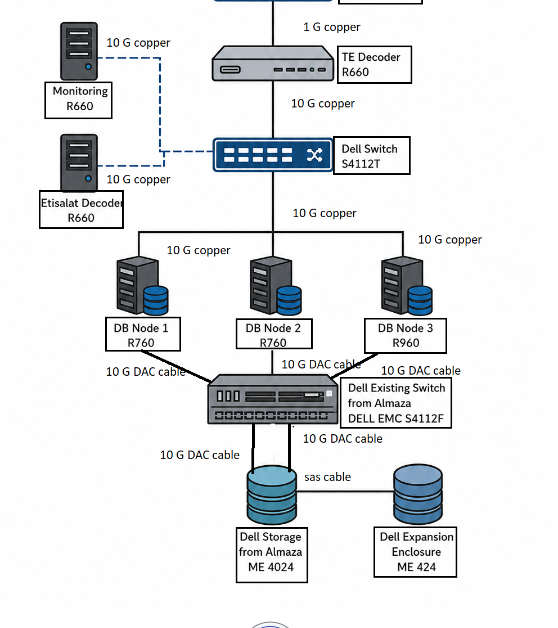

What is serviceacount ,what is it, why i use it ?
when i think when to use it?

for exmaple flennal how service why have it ?

kubectl get serviceaccounts --all-namespaces -o wide
NAMESPACE         NAME                                          AGE
default           default                                       24h
headlamp          default                                       23h
headlamp          my-headlamp                                   23h
ingress-nginx     default                                       23h
ingress-nginx     ingress-nginx                                 23h
kube-flannel      default                                       24h
kube-flannel      flannel                                       24h


In [ ]:
what is CNI like Flennel?
why the cluster need it ?
It normal the cluster should can talk with pod without any outide network element like docker can as example it create container the container can talk with each other 

In [ ]:
more question about storage , application 
what the app is done?
the read or write?
where the app will be installed (on any node) ?

---

Block vs filesystem: Yes, iSCSI is raw block. You then lay a filesystem on it (XFS for Option A, GFS2 for Option B, or give the raw device directly to Ceph as an OSD for Option C).
The full guide is above. Here are the direct answers to all your questions:One writer, automatic failover: Option A is exactly this. Pacemaker enforces that only one node ever has the mount. When it dies, STONITH power-kills it via iDRAC (confirms it stopped writing), then the mount moves to heavy-2 automatically in 30–60 seconds.
NFS speed: Not slow when configured correctly. With NFSv4.1, 1 MB block size, and hard,nointr options over 10 GbE, you get 900–1100 MB/s — your ME4024 is the actual bottleneck, not NFS. ClickHouse writes large sequential files which are ideal for NFS.
/srv/xdr/pv-root location: Only on the three heavy nodes. The NFS CSI driver automatically mounts it into pods — no manual NFS mount on any worker node.
The VIP: Pacemaker-managed OS-level IP, completely separate from kube-vip (API server) and MetalLB (ingress). Three different VIPs, three different purposes, no conflict.
iDRAC: You must enable "IPMI over LAN" in iDRAC settings and make sure the management network is reachable. Without it, STONITH fails. Without STONITH, you risk XFS corruption if a node half-dies.
GFS2: Yes, all three nodes mount simultaneously and can all write at the same time. DLM coordinates locks. No failover needed because all nodes are always active.
Rook/Ceph speed: Somewhat slower than direct block (~20–30% overhead), but adequate for ClickHouse. The big catch is you should split the 60 TB into 3 × 20 TB LUNs on the ME4024, one per heavy node — so Ceph can replicate across three failure domains

# Kubernetes Shared Storage — Production HA Guide
## XDR Decoder Cluster — ME4024 iSCSI Backend

---

## Part 0 — Your Questions Answered

### Q: "I will see the storage as block — is that correct?"

**Yes, exactly correct.**

iSCSI presents a raw **block device** to the OS — identical to a local SAS/SATA disk.
You see it as `/dev/sdb` or `/dev/mapper/xdr-data` (via multipath). There is no filesystem
on the wire — just sectors. You then decide what to put on top:

| Layer | Option A | Option B | Option C |
|---|---|---|---|
| Block device | `/dev/mapper/xdr-data` | `/dev/mapper/xdr-data` | `/dev/mapper/xdr-data` as raw OSD |
| Filesystem | XFS (single-mount) | GFS2 (cluster-mount) | None — Ceph owns the raw device |
| Export to K8s | NFS via VIP | hostPath or NFS | CephFS / RBD via CSI |

The ME4024 has no knowledge of filesystems. It stores and returns sectors.
All intelligence (locking, failover, access control) lives in the software stack above it.

---

### Q: "I want only one VM to write — to stay away from interrupted data"

**Option A is exactly the right choice for you.** This is called **active-passive** storage:

- At any moment, exactly ONE heavy node has the iSCSI LUN mounted and running NFS-Ganesha.
- The other two nodes have their iSCSI sessions connected but the LUN is **not mounted** —
  they can see it, they cannot touch it.
- When the active node dies, Pacemaker:
  1. STONITH-fences the dead node (cuts power via iDRAC) — confirms it cannot write.
  2. Mounts the LUN on the next heavy node.
  3. Starts NFS-Ganesha on the new node.
  4. Moves the floating VIP to the new node.
  5. NFS clients (your pods) reconnect automatically via the VIP.
- Total automatic failover time: **30–60 seconds**.
- No human involvement. No manual mount command. No phone calls at 3 AM.

---

### Q: "NFS is slow? The data will be huge"

NFS over 10 GbE **is fast when configured correctly**. Here is the math for your setup:

```
ME4024 sequential write throughput (RAID-6, 10K SAS, write-back cache):
  ~ 800–1200 MB/s sustained (your fio acceptance test measures this)

10 GbE NFS theoretical ceiling:
  10 Gbit/s ÷ 8 = 1250 MB/s

Real-world NFSv4.1 with tuning on 10 GbE:
  ~ 900–1100 MB/s sequential (within 15% of direct-mount XFS)
```

The storage array — not NFS — is your actual bottleneck. NFS adds CPU overhead and
protocol latency, not bandwidth. With these mount options you recover most of that:

```bash
# /etc/fstab entry on ALL Kubernetes nodes (or in your NFS CSI StorageClass):
<storage-vip>:/srv/xdr/pv-root  /mnt/nfs  nfs4  \
  rw,hard,nointr,tcp,vers=4.1,\
  rsize=1048576,wsize=1048576,\   # 1 MB read/write block — matches ClickHouse write size
  timeo=600,retrans=2,\
  noacl,noatime,nodiratime        # reduce metadata overhead

# NFS-Ganesha export (on the Pacemaker-managed node):
# In /etc/ganesha/ganesha.conf — disable SYNC for the data export:
EXPORT {
    Export_Id = 1;
    Path = "/srv/xdr/pv-root";
    Pseudo = "/xdr";
    Protocols = 4;
    Transports = TCP;
    Access_Type = RW;
    Squash = No_Root_Squash;
    FSAL { Name = VFS; }

    # IMPORTANT: async mode — lets the BBU-backed ME4024 cache absorb writes
    # Durability = RAID-6 + BBU, not NFS sync
    Attr_Expiration_Time = 1;
}
```

**ClickHouse specifically:** ClickHouse writes in large sequential column files, typically
1–512 MB per file. With 1 MB NFS block size this maps perfectly to single NFS RPC calls.
You will NOT see NFS as a performance problem for ClickHouse at this scale.

---

### Q: "`/srv/xdr/pv-root` — should this exist on ALL workers?"

**No. Only on the three heavy nodes.**

Here is exactly what lives where:

```
Heavy-1 (Pacemaker active node):
  /srv/xdr/pv-root  ← XFS filesystem mounted here (iSCSI LUN)
                       NFS-Ganesha EXPORTS this directory

Heavy-2, Heavy-3 (Pacemaker standby):
  /srv/xdr/pv-root  ← empty directory, exists in case Pacemaker fails over here
                       the LUN is NOT mounted here while heavy-1 is healthy

Light-1, Light-2, Light-3 (no storage NIC):
  → nothing. They have no iSCSI connection and no /srv/xdr path.

Kubernetes pods (on any node — heavy or light):
  → the NFS CSI driver mounts the NFS share automatically when a PVC is bound.
     Pods never see /srv/xdr directly. They see /var/lib/kubelet/pods/<uid>/volumes/...
     which the CSI driver bind-mounts from the NFS share.
```

**The NFS CSI driver handles all of this automatically.** You do not manually mount NFS
on any worker node. When a pod with an NFS-backed PVC is scheduled:

1. kubelet calls the NFS CSI node plugin.
2. The CSI plugin mounts `<storage-vip>:/srv/xdr/pv-root/<pvc-name>` on the node.
3. The directory is bind-mounted into the container.
4. When the pod is deleted, it is unmounted.

---

### Q: "The floating VIP — is it used by Kubernetes or the OS? Will it conflict with kube-vip and MetalLB?"

**It is an OS-level IP managed by Pacemaker. It does not conflict with kube-vip or MetalLB
because they serve completely different purposes.**

You have three separate VIPs in your cluster:

```
┌─────────────────────────────────────────────────────────────────┐
│  VIP 1 — kube-vip (e.g. 10.0.0.100)                            │
│  Managed by: kube-vip static pod on control-plane nodes         │
│  Purpose: Kubernetes API server (:6443)                         │
│  Who uses it: kubectl, kubelet, all cluster components          │
│  Where it lives: control-plane nodes (masters)                  │
├─────────────────────────────────────────────────────────────────┤
│  VIP 2 — MetalLB pool (e.g. 10.0.1.10–10.0.1.50)              │
│  Managed by: MetalLB speaker daemonset                          │
│  Purpose: LoadBalancer services (nginx ingress, etc.)           │
│  Who uses it: external users, DNS records                       │
│  Where it lives: announced via ARP/BGP on ToR switch            │
├─────────────────────────────────────────────────────────────────┤
│  VIP 3 — Pacemaker storage VIP (e.g. 10.0.0.200)              │
│  Managed by: Pacemaker (corosync) on heavy nodes               │
│  Purpose: NFS server endpoint for pods to reach NFS-Ganesha     │
│  Who uses it: the NFS CSI driver on all K8s nodes              │
│  Where it lives: cluster network (ToR VLAN, same as pod traffic)│
│  Visibility: internal only — pods and nodes, not external users │
└─────────────────────────────────────────────────────────────────┘
```

The Pacemaker VIP is just an IP address that Pacemaker adds/removes from a NIC using
`ip addr add / ip addr del`. It sits on the same network interface as the cluster NIC
(`bond0` / `ens3f0` etc.) and appears on the ToR switch like any other node IP.

**Your Windows DNS server does NOT need a record for this VIP** — only the NFS CSI
StorageClass needs to know it (the IP goes directly in the StorageClass `server` parameter).

**Reserve this IP in your IPAM/DHCP exclusion table** exactly as you did for the kube-vip VIP.

---

### Q: "iDRAC — should I change any configuration? What if I do nothing?"

**Yes, you must do three things in iDRAC. If you skip this, Pacemaker STONITH will fail.**

#### Required iDRAC configuration (on each heavy node):

```
1. Enable IPMI over LAN
   iDRAC GUI → iDRAC Settings → Connectivity → IPMI Settings
   → Enable IPMI over LAN: ON
   → Encryption key: leave as 0000...0 (or set one and use it in fence_ipmilan)
   → Privilege level: OPERATOR or ADMINISTRATOR

2. Ensure iDRAC has a static IP on the management network
   iDRAC GUI → iDRAC Settings → Connectivity → Network
   → IP address: 10.x.x.x (your management VLAN)
   → This must be reachable from ALL three heavy nodes

3. Create a dedicated fence user (do not use root)
   iDRAC GUI → iDRAC Settings → Users → Add User
   → Username: fence-agent
   → Role: OPERATOR (minimum required for power control)
   → Store password in Pacemaker, not in plain text files
```

#### What happens if you do NOTHING (leave STONITH unconfigured):

```
Scenario: heavy-1 crashes mid-write (kernel panic, OOM killer, power loss)

Without STONITH:
  → heavy-1 OS is dead but iSCSI session may still be "open" from ME4024's view
  → Pacemaker sees heavy-1 is gone but cannot confirm it stopped writing
  → Pacemaker REFUSES to mount the LUN on heavy-2 (correct behaviour!)
  → Your storage is DOWN until a human physically verifies heavy-1 is off
  → If you force Pacemaker to ignore this (stonith-enabled=false):
    → Pacemaker mounts the LUN on heavy-2
    → If heavy-1's kernel somehow recovers mid-mount: TWO NODES WRITE XFS SIMULTANEOUSLY
    → XFS CORRUPTION. Data loss. Non-recoverable without backup.

With STONITH (fence_ipmilan):
  → Pacemaker detects heavy-1 is gone
  → Sends IPMI command: "power off heavy-1" to heavy-1's iDRAC
  → iDRAC cuts power — confirmed via IPMI response
  → Pacemaker KNOWS heavy-1 cannot write — mounts on heavy-2
  → Automatic. Safe. No data corruption risk.
```

**STONITH is not optional for shared block storage. It is the safety pin.**

---

### Q: "Option B — GFS2: do I mount the disk on all three heavy nodes? Do all three write at the same time?"

**Yes and yes.** This is the key difference from Option A:

```
Option A (Pacemaker + NFS):     Option B (GFS2):
  heavy-1: MOUNTED, writing        heavy-1: MOUNTED, writing
  heavy-2: NOT mounted (standby)   heavy-2: MOUNTED, writing simultaneously
  heavy-3: NOT mounted (standby)   heavy-3: MOUNTED, writing simultaneously

Failover time: 30–60 s            Failover time: 0 s (node fails, others continue)
```

GFS2 uses a **Distributed Lock Manager (DLM)** — also managed by Pacemaker/Corosync —
to coordinate writes. When heavy-2 wants to write to a file that heavy-1 has locked,
heavy-2 waits for heavy-1 to release the lock. This adds latency for small random writes.

**GFS2 performance profile:**
- Sequential large writes (like ClickHouse): near-identical to XFS, DLM locks rarely contend
- Small random writes (like database indexes, logs): 20–40% slower than XFS due to lock overhead
- Read: identical to XFS (reads do not require exclusive locks)

**You still need Pacemaker and STONITH with GFS2.** The DLM journal recovery requires
knowing a failed node is truly dead before replaying its journal on the surviving nodes.
Without STONITH: a failed node that "recovers" after journal replay = corrupted GFS2.

**When to choose GFS2 over Option A:**
- You have multiple applications that each need their own active writer across all nodes
- 30–60 s failover time is unacceptable for your SLA
- You do NOT want an NFS layer in the path (GFS2 is direct block access from all nodes)

**For your ClickHouse use case:** Option A (NFS) is simpler and sufficient. Choose GFS2
only if you need failover under 5 seconds or if you have other workloads that write from
multiple pods on different nodes simultaneously.

---

### Q: "Option C — Rook/Ceph: can I only work with disks across Kubernetes? Is it fast?"

**Correct — Rook/Ceph is 100% Kubernetes-native.** You manage everything through
`kubectl` and Kubernetes CRDs. There is no Pacemaker, no manual mount, no NFS-Ganesha.
Ceph handles its own failure detection and recovery internally.

**Performance depends on your OSD layout.** See Part 3 below for details.

---

## Part 1 — Option A: Pacemaker + NFS-Ganesha (Full Implementation)

### Architecture

```
                    [ Kubernetes Pods — any node ]
                           |
                   (NFS mount via CSI driver)
                           |
              ┌────────────▼─────────────┐
              │   Storage VIP (10.x.x.y) │  ← Pacemaker moves this IP
              └────────────┬─────────────┘     between heavy nodes on failure
                           |
        ┌──────────────────┼──────────────────┐
        │                  │                  │
   [heavy-1]          [heavy-2]          [heavy-3]
   ACTIVE             STANDBY            STANDBY
   iSCSI: mounted     iSCSI: session up  iSCSI: session up
   XFS: mounted       XFS: NOT mounted   XFS: NOT mounted
   NFS-Ganesha: up    NFS-Ganesha: off   NFS-Ganesha: off
        │
        └──────── iSCSI ──────────────────────────────
                                                       |
                                          [ ME4024 LUN — /dev/mapper/xdr-data ]
```

### Step 1: Packages (all three heavy nodes)

```bash
dnf install -y pacemaker corosync fence-agents-ipmilan \
               pcs nfs-ganesha nfs-ganesha-vfs \
               open-iscsi device-mapper-multipath

systemctl enable --now pcsd
```

Set the `hacluster` password (same on all nodes):
```bash
echo "YourStrongPassword" | passwd --stdin hacluster
```

Firewall rules:
```bash
firewall-cmd --permanent --add-service=high-availability
firewall-cmd --permanent --add-service=nfs
firewall-cmd --permanent --add-service=nfs3      # for older clients if needed
firewall-cmd --permanent --add-port=2049/tcp
firewall-cmd --reload
```

### Step 2: Bootstrap the Pacemaker cluster (run from heavy-1 only)

```bash
pcs host auth heavy-1 heavy-2 heavy-3 \
    -u hacluster -p YourStrongPassword

pcs cluster setup storage-ha-cluster \
    heavy-1 addr=10.0.0.11 \
    heavy-2 addr=10.0.0.12 \
    heavy-3 addr=10.0.0.13

pcs cluster start --all
pcs cluster enable --all

# Verify all three nodes joined:
pcs status
```

### Step 3: Configure STONITH (fence via iDRAC)

```bash
# One fence device per node — each node fences the OTHER nodes
# heavy-1's fence device (fences heavy-1 — i.e. called by heavy-2 or heavy-3):
pcs stonith create fence-heavy1 fence_ipmilan \
    pcmk_host_list="heavy-1" \
    ipaddr="10.0.0.101" \    # heavy-1's iDRAC IP
    login="fence-agent" \
    passwd="FencePassword" \
    lanplus=1 \
    action=reboot \
    op monitor interval=60s

pcs stonith create fence-heavy2 fence_ipmilan \
    pcmk_host_list="heavy-2" \
    ipaddr="10.0.0.102" \
    login="fence-agent" passwd="FencePassword" lanplus=1 action=reboot \
    op monitor interval=60s

pcs stonith create fence-heavy3 fence_ipmilan \
    pcmk_host_list="heavy-3" \
    ipaddr="10.0.0.103" \
    login="fence-agent" passwd="FencePassword" lanplus=1 action=reboot \
    op monitor interval=60s

# Location constraints: each node must NOT fence itself
pcs constraint location fence-heavy1 avoids heavy-1
pcs constraint location fence-heavy2 avoids heavy-2
pcs constraint location fence-heavy3 avoids heavy-3

# Test STONITH before proceeding (will reboot heavy-2!):
pcs stonith fence heavy-2 --wait
# heavy-2 should power off then back on. Wait for it to rejoin:
pcs status
```

### Step 4: Configure NFS-Ganesha

Create `/etc/ganesha/ganesha.conf` on ALL THREE heavy nodes (identical content):

```
NFS_CORE_PARAM {
    NFS_Port = 2049;
    Protocols = 4;
}

EXPORT_DEFAULTS {
    Access_Type = None;
}

EXPORT {
    Export_Id = 1;
    Path = "/srv/xdr/pv-root";
    Pseudo = "/xdr";
    Protocols = 4;
    Transports = TCP;
    Access_Type = RW;
    Squash = No_Root_Squash;

    CLIENT {
        Clients = 10.0.0.0/24;    # your cluster network CIDR
        Access_Type = RW;
        Squash = No_Root_Squash;
    }

    FSAL {
        Name = VFS;
    }
}

LOG {
    Default_Log_Level = WARN;
    Components {
        FSAL = INFO;
        NFS4 = WARN;
    }
}
```

Disable the NFS-Ganesha systemd service (Pacemaker will control it, not systemd):
```bash
systemctl disable nfs-ganesha
systemctl stop nfs-ganesha    # make sure it is not running
```

### Step 5: Create the Pacemaker resource group

```bash
# The floating VIP — choose a free IP on your cluster network
pcs resource create storage-vip IPaddr2 \
    ip=10.0.0.200 \           # ← your chosen storage VIP
    cidr_netmask=24 \
    nic=bond0 \               # ← your cluster NIC name
    op monitor interval=10s timeout=20s

# The iSCSI LUN filesystem mount
pcs resource create storage-lun Filesystem \
    device="/dev/mapper/xdr-data" \
    directory="/srv/xdr/pv-root" \
    fstype="xfs" \
    options="noatime,nodiratime,inode64,logbsize=256k" \
    op start timeout=90s \
    op stop  timeout=90s \
    op monitor interval=20s timeout=40s

# NFS-Ganesha server
pcs resource create nfs-ganesha systemd:nfs-ganesha \
    op start   timeout=30s \
    op stop    timeout=30s \
    op monitor interval=10s timeout=20s

# Group them — Pacemaker starts in ORDER: VIP → LUN → Ganesha
# On failover: stops in REVERSE order: Ganesha → LUN → VIP
pcs resource group add storage-group \
    storage-vip storage-lun nfs-ganesha

# Force the group to prefer heavy-1 (optional but good practice)
pcs constraint location storage-group prefers heavy-1=100 heavy-2=50 heavy-3=25

# Verify:
pcs status
pcs resource show storage-group
```

### Step 6: Kubernetes — NFS CSI StorageClass

Install the NFS CSI driver in your cluster:
```bash
helm repo add csi-driver-nfs https://raw.githubusercontent.com/kubernetes-csi/csi-driver-nfs/master/charts
helm install csi-driver-nfs csi-driver-nfs/csi-driver-nfs \
    --namespace kube-system \
    --set kubeletDir=/var/lib/kubelet
```

Create the StorageClass:
```yaml
# storage-class-nfs.yaml
apiVersion: storage.k8s.io/v1
kind: StorageClass
metadata:
  name: shared-storage
  annotations:
    storageclass.kubernetes.io/is-default-class: "false"
provisioner: nfs.csi.k8s.io
parameters:
  server: "10.0.0.200"          # ← your Pacemaker storage VIP
  share: "/xdr"                 # ← the Ganesha Pseudo path
  subDir: "${pvc.metadata.namespace}/${pvc.metadata.name}"
  mountPermissions: "0755"
mountOptions:
  - hard
  - nointr
  - nfsvers=4.1
  - rsize=1048576
  - wsize=1048576
  - timeo=600
  - retrans=2
  - noatime
  - nodiratime
reclaimPolicy: Retain           # NEVER Delete in production — human must verify before purge
volumeBindingMode: Immediate
allowVolumeExpansion: false     # NFS subdirs cannot be expanded; resize at array level
```

```bash
kubectl apply -f storage-class-nfs.yaml
```

### Step 7: ClickHouse PVC example

```yaml
# clickhouse-pvc.yaml
apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: clickhouse-data
  namespace: clickhouse
spec:
  accessModes:
    - ReadWriteOnce      # One pod writes — correct for ClickHouse
  storageClassName: shared-storage
  resources:
    requests:
      storage: 20Ti      # ClickHouse gets 20 TB out of your 60 TB LUN subdir
```

---

## Part 2 — Option B: GFS2 (Simultaneous Multi-Node Write)

### Architecture

```
        ┌──────────┐    ┌──────────┐    ┌──────────┐
        │ heavy-1  │    │ heavy-2  │    │ heavy-3  │
        │          │    │          │    │          │
        │ GFS2     │    │ GFS2     │    │ GFS2     │
        │ MOUNTED  │    │ MOUNTED  │    │ MOUNTED  │
        │ READ+WRITE│   │ READ+WRITE│   │ READ+WRITE│
        └────┬─────┘    └────┬─────┘    └────┬─────┘
             │               │               │
             └───────────────┼───────────────┘
                             │
                    DLM lock coordination
                    (via Pacemaker/Corosync)
                             │
                  [ ME4024 — /dev/mapper/xdr-data ]
```

### Setup

```bash
# Install on all three heavy nodes:
dnf install -y gfs2-utils dlm lvm2-cluster pacemaker corosync pcs \
               fence-agents-ipmilan

# Configure Pacemaker + STONITH (same as Option A, Steps 1–3)
# Then add the DLM resource:

pcs resource create dlm ocf:pacemaker:controld \
    op start timeout=90s op stop timeout=100s op monitor interval=30s timeout=90s \
    clone interleave=true ordered=true

# Format the LUN as GFS2 (run ONCE from heavy-1 — destroys existing data):
mkfs.gfs2 -p lock_dlm \
    -t storage-ha-cluster:xdr-data \   # cluster_name:filesystem_name
    -j 3 \                              # 3 journals, one per node
    /dev/mapper/xdr-data

# Mount resource — cloned (runs on ALL nodes simultaneously):
pcs resource create gfs2-mount Filesystem \
    device="/dev/mapper/xdr-data" \
    directory="/srv/xdr/pv-root" \
    fstype="gfs2" \
    options="noatime,nodiratime" \
    op start timeout=90s op stop timeout=90s op monitor interval=20s timeout=40s \
    clone interleave=true

# DLM must start before GFS2 on every node:
pcs constraint order start dlm-clone then gfs2-mount-clone
pcs constraint colocation add gfs2-mount-clone with dlm-clone

pcs status
```

For Kubernetes with GFS2, you have two choices:
1. Use NFS-Ganesha ON TOP of GFS2 (same as Option A but all three nodes can be NFS servers simultaneously — use a round-robin DNS record instead of a single VIP).
2. Use `local-path-provisioner` with `nodeAffinity` pinning pods to specific heavy nodes
   (simpler, no NFS layer, but pods cannot move between heavy nodes freely).

---

## Part 3 — Option C: Rook/Ceph (Full Detail)

### What Rook/Ceph is

```
┌──────────────────────────────────────────────────────────┐
│                  Kubernetes cluster                       │
│                                                          │
│  ┌────────────┐   ┌────────────┐   ┌────────────┐       │
│  │  heavy-1   │   │  heavy-2   │   │  heavy-3   │       │
│  │            │   │            │   │            │       │
│  │  ceph-osd  │   │  ceph-osd  │   │  ceph-osd  │       │
│  │  ceph-mgr  │   │            │   │            │       │
│  │  ceph-mon  │   │  ceph-mon  │   │  ceph-mon  │       │
│  └────────────┘   └────────────┘   └────────────┘       │
│       │                │                │                 │
│       └────────────────┼────────────────┘                 │
│                        │                                  │
│              Ceph RADOS object store                      │
│              (handles replication, placement,             │
│               failure detection, repair internally)       │
│                        │                                  │
│         ┌──────────────┼──────────────┐                  │
│         │              │              │                   │
│    RBD (block)   CephFS (file)   RGW (S3)                │
│    ReadWriteOnce  ReadWriteMany  Object storage           │
│         │              │                                  │
│    ClickHouse    ClickHouse logs                          │
│    single-shard  multi-writer                             │
└──────────────────────────────────────────────────────────┘
```

Rook is a Kubernetes **operator** — a controller running as a pod that watches CRD objects
and manages Ceph cluster lifecycle. You create a `CephCluster` CRD and Rook does the rest.

### The critical question: how do you give Ceph your 60 TB?

#### Problem with a single 60 TB LUN

A standard Ceph deployment uses **one OSD per physical disk**. With a single 60 TB LUN,
Ceph has exactly 1 OSD. This means:

- No replication possible (replication requires ≥ 2 OSDs on ≥ 2 nodes)
- Any Ceph-level write failure = data unavailable
- You are relying 100% on the ME4024's own RAID-6 for durability
- The OSD daemon is a single point of failure even though the data is RAID-protected

This works but loses most of Ceph's value.

#### Better: re-partition the ME4024 into 3 LUNs (recommended for Ceph)

Instead of one 60 TB LUN, ask the ME4024 to present **three 20 TB LUNs**, one per heavy node.
Each LUN is an independent Ceph OSD. This gives you:

- 3 OSDs across 3 failure domains (1 OSD per host)
- Ceph can replicate data 3x (default replication factor = 3 copies, 0 data loss if 1 node fails)
- OR use erasure coding 2+1 (~33% overhead, mathematically equivalent to RAID-5 but distributed)

```bash
# On ME4024 — using the Dell storage manager or CLI:
# Delete the existing single LUN (BACK UP ALL DATA FIRST)
# Create three LUNs:
#   xdr-data-1: 20 TB, mapped to heavy-1 IQN only
#   xdr-data-2: 20 TB, mapped to heavy-2 IQN only
#   xdr-data-3: 20 TB, mapped to heavy-3 IQN only
# Each heavy node sees its own 20 TB block device via multipath
```

With 3-way replication, usable capacity = 20 TB (each byte written 3 times across 3 nodes).
With erasure coding 2+1, usable capacity = 40 TB (good compromise).

### Step-by-step installation

#### Step 1: Prepare the raw devices

On each heavy node — verify the iSCSI LUN is visible but has NO filesystem:
```bash
# On heavy-1:
lsblk /dev/mapper/xdr-data-1
# Must show: no filesystem, no partitions, raw block device

# Zero the first 10 MB to remove any previous filesystem signatures:
dd if=/dev/zero of=/dev/mapper/xdr-data-1 bs=1M count=10

# Do the same on heavy-2 (xdr-data-2) and heavy-3 (xdr-data-3)
```

#### Step 2: Install Rook operator

```bash
# Add the Rook Helm repository:
helm repo add rook-release https://charts.rook.io/release
helm repo update

# Install the operator into its own namespace:
helm install --create-namespace \
    --namespace rook-ceph \
    rook-ceph rook-release/rook-ceph \
    --set enableDiscoveryDaemon=true

# Wait for the operator to be ready:
kubectl -n rook-ceph rollout status deploy/rook-ceph-operator
```

#### Step 3: Create the CephCluster CRD

```yaml
# ceph-cluster.yaml
apiVersion: ceph.rook.io/v1
kind: CephCluster
metadata:
  name: rook-ceph
  namespace: rook-ceph
spec:
  cephVersion:
    image: quay.io/ceph/ceph:v18          # Ceph Reef (latest stable)
    allowUnsupported: false

  dataDirHostPath: /var/lib/rook          # Ceph state — uses local disk, NOT the LUN

  mon:
    count: 3                              # 3 monitors — quorum requires odd number ≥ 3
    allowMultiplePerNode: false

  mgr:
    count: 1

  dashboard:
    enabled: true
    ssl: true

  network:
    provider: host                        # Use host network for best performance
    # Separate cluster and public networks if you have them:
    # cluster: 10.0.20.0/24              # iSCSI/storage VLAN
    # public:  10.0.0.0/24              # cluster VLAN

  storage:
    useAllNodes: false                    # NEVER use all nodes — heavy only
    useAllDevices: false                  # NEVER auto-discover — specify devices exactly

    nodes:
      - name: "heavy-1"
        devices:
          - name: "/dev/mapper/xdr-data-1"   # the 20 TB LUN on heavy-1
            config:
              osdsPerDevice: "1"
      - name: "heavy-2"
        devices:
          - name: "/dev/mapper/xdr-data-2"
            config:
              osdsPerDevice: "1"
      - name: "heavy-3"
        devices:
          - name: "/dev/mapper/xdr-data-3"
            config:
              osdsPerDevice: "1"

  # Placement — Ceph daemons only go on heavy nodes:
  placement:
    all:
      nodeAffinity:
        requiredDuringSchedulingIgnoredDuringExecution:
          nodeSelectorTerms:
            - matchExpressions:
                - key: workload-class
                  operator: In
                  values:
                    - heavy

  resources:
    osd:
      requests:
        cpu: "2"
        memory: "4Gi"
      limits:
        cpu: "4"
        memory: "8Gi"
    mon:
      requests:
        cpu: "500m"
        memory: "1Gi"
```

```bash
kubectl apply -f ceph-cluster.yaml

# Watch the cluster come up (takes 5–10 minutes):
kubectl -n rook-ceph get pods -w

# Check health:
kubectl -n rook-ceph exec -it deploy/rook-ceph-tools -- ceph status
# Expected: HEALTH_OK, 3 osds up, 3 monitors
```

#### Step 4: Create a CephBlockPool and StorageClass (for ClickHouse)

```yaml
# ceph-block.yaml
apiVersion: ceph.rook.io/v1
kind: CephBlockPool
metadata:
  name: replicapool
  namespace: rook-ceph
spec:
  failureDomain: host                   # replicate across hosts, not just OSDs
  replicated:
    size: 3                             # 3 copies — survives 1 node failure
    requireSafeReplicaSize: true        # refuse writes if < 2 replicas available
---
apiVersion: storage.k8s.io/v1
kind: StorageClass
metadata:
  name: ceph-block
provisioner: rook-ceph.rbd.csi.ceph.com
parameters:
  clusterID: rook-ceph
  pool: replicapool
  imageFormat: "2"
  imageFeatures: layering
  csi.storage.k8s.io/provisioner-secret-name: rook-csi-rbd-provisioner
  csi.storage.k8s.io/provisioner-secret-namespace: rook-ceph
  csi.storage.k8s.io/controller-expand-secret-name: rook-csi-rbd-provisioner
  csi.storage.k8s.io/controller-expand-secret-namespace: rook-ceph
  csi.storage.k8s.io/node-stage-secret-name: rook-csi-rbd-node
  csi.storage.k8s.io/node-stage-secret-namespace: rook-ceph
reclaimPolicy: Retain
allowVolumeExpansion: true
mountOptions:
  - discard
```

```bash
kubectl apply -f ceph-block.yaml
```

#### Step 5: Create a CephFilesystem (for multi-writer workloads)

```yaml
# ceph-filesystem.yaml
apiVersion: ceph.rook.io/v1
kind: CephFilesystem
metadata:
  name: xdr-fs
  namespace: rook-ceph
spec:
  metadataPool:
    replicated:
      size: 3
  dataPools:
    - name: data0
      failureDomain: host
      replicated:
        size: 3
  preserveFilesystemOnDelete: true      # IMPORTANT: don't delete data if CRD is removed
  metadataServer:
    activeCount: 1
    activeStandby: true                 # hot standby MDS for fast failover
    placement:
      nodeAffinity:
        requiredDuringSchedulingIgnoredDuringExecution:
          nodeSelectorTerms:
            - matchExpressions:
                - key: workload-class
                  operator: In
                  values:
                    - heavy
---
apiVersion: storage.k8s.io/v1
kind: StorageClass
metadata:
  name: ceph-filesystem
provisioner: rook-ceph.cephfs.csi.ceph.com
parameters:
  clusterID: rook-ceph
  fsName: xdr-fs
  pool: xdr-fs-data0
  csi.storage.k8s.io/provisioner-secret-name: rook-csi-cephfs-provisioner
  csi.storage.k8s.io/provisioner-secret-namespace: rook-ceph
  csi.storage.k8s.io/controller-expand-secret-name: rook-csi-cephfs-provisioner
  csi.storage.k8s.io/controller-expand-secret-namespace: rook-ceph
  csi.storage.k8s.io/node-stage-secret-name: rook-csi-cephfs-node
  csi.storage.k8s.io/node-stage-secret-namespace: rook-ceph
reclaimPolicy: Retain
allowVolumeExpansion: true
```

```bash
kubectl apply -f ceph-filesystem.yaml
```

#### Step 6: ClickHouse with Ceph

```yaml
# clickhouse-pvc-ceph.yaml
apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: clickhouse-data-shard1
  namespace: clickhouse
spec:
  accessModes:
    - ReadWriteOnce             # Ceph RBD — one pod writer, fastest for databases
  storageClassName: ceph-block
  resources:
    requests:
      storage: 10Ti

# For shared log directories across pods — use CephFS:
---
apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: clickhouse-shared-logs
  namespace: clickhouse
spec:
  accessModes:
    - ReadWriteMany             # CephFS — multiple pods can write simultaneously
  storageClassName: ceph-filesystem
  resources:
    requests:
      storage: 1Ti
```

### Ceph performance characteristics

| Operation | 3-OSD Ceph (3-way replication) | Direct XFS on ME4024 |
|---|---|---|
| Sequential write | ~600–800 MB/s | ~800–1200 MB/s |
| Sequential read | ~900–1100 MB/s | ~1000–1200 MB/s |
| Random 4K write IOPS | ~5,000–15,000 | ~10,000–20,000 |
| Latency (write) | ~2–5 ms | ~1–2 ms |
| Replication | 3 copies (survives 1 node loss) | ME4024 RAID-6 only |
| Failover time | ~10–30 s (automatic) | N/A (no failover) |

Ceph is slower than direct block access because every write must reach 2+ OSDs before
acknowledging. For ClickHouse (large sequential writes, 50–500 MB/s per shard), Ceph
throughput is more than adequate.

---

## Part 4 — Decision Matrix for Your Environment

| Criterion | Option A: Pacemaker+NFS | Option B: GFS2 | Option C: Rook/Ceph |
|---|---|---|---|
| Automatic failover | Yes (30–60 s) | No failover (all nodes active) | Yes (~15 s) |
| One writer at a time | Yes (your requirement) | No — all nodes write | Yes (RBD = one writer) |
| Implementation complexity | Medium | Medium-high | High |
| RHEL native support | Yes — Red Hat HA Add-On | Yes — included in RHEL HA | Community (CNCF) |
| Requires Pacemaker/STONITH | Yes | Yes | No |
| ME4024 reconfiguration | Not needed | Not needed | Recommended (3 LUNs) |
| Kubernetes integration | NFS CSI driver | local-path or NFS CSI | Native Ceph CSI |
| ClickHouse recommended | Yes | Yes | Yes (use RBD) |
| Multiple apps sharing storage | Yes (NFS subdirs) | Yes (GFS2 subdirs) | Yes (separate PVCs) |
| Future scalability | Add array → re-export | Add array → grow GFS2 | Add OSD → rebalances automatically |
| **Recommended for your setup** | ✅ **Best fit** | ⚠️ if SLA < 30 s | ⚠️ if adding more raw disks later |

### Final Recommendation

**Implement Option A now.** It matches your requirement exactly (one writer, automatic
failover, RHEL native). Red Hat HA (pacemaker + corosync + fence-agents) is fully
supported under your RHEL subscription.

**Plan for Option C in 12–24 months** if you need to add more storage capacity or if you
add more workloads that need true distributed storage. At that point, re-partitioning the
ME4024 into per-node LUNs and adding a Rook/Ceph layer on top gives you the most
flexibility with zero impact on the Kubernetes application layer (just change the
StorageClass name in your PVCs).

---

## Part 5 — Monitoring Your Storage HA

### Pacemaker health checks

```bash
# Quick cluster health:
pcs status

# Watch for failover events:
journalctl -u corosync -f
journalctl -u pacemaker -f

# Verify the NFS-Ganesha export is reachable from any node:
showmount -e 10.0.0.200      # your storage VIP

# Test NFS read/write from a non-heavy node:
mount -t nfs4 10.0.0.200:/xdr /mnt/test
dd if=/dev/zero of=/mnt/test/testfile bs=1M count=1000
# Expect: ~900 MB/s if tuning is correct
umount /mnt/test
```

### Simulate a failover (test before go-live)

```bash
# Graceful failover — move the resource group to heavy-2:
pcs resource move storage-group heavy-2

# Watch failover happen in real time:
watch -n1 pcs status

# Verify NFS is now served from heavy-2:
showmount -e 10.0.0.200     # still responds — VIP moved

# Hard failover — simulate heavy-1 kernel panic:
# (run from heavy-2 or heavy-3 — this WILL reboot heavy-1)
ipmitool -I lanplus -H 10.0.0.101 -U fence-agent -P FencePassword chassis power off
watch -n1 pcs status        # watch Pacemaker fence and recover

# After test — clear the move constraint:
pcs resource clear storage-group
```

### Kubernetes storage health

```bash
# Check PVCs are bound:
kubectl get pvc -A

# Check NFS CSI pods:
kubectl -n kube-system get pods | grep csi-nfs

# Check a specific PVC mount inside a pod:
kubectl -n clickhouse exec clickhouse-0 -- df -h /var/lib/clickhouse
```